#### Assessing motion energy by using pymoten

See https://gallantlab.org/pymoten/. It takes a while to run. You can use the editing code to reduce the size of the videos, or work on just some frames etc for your first run to get an initial sense.

In [ ]:
import os
import numpy as np
import moten
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import warnings

# ----------------------
# SETTINGS
# ----------------------
base_dir = "/Users/sedaakbiyik/Dropbox/Stanford/Projects/dyloc_development/stimuli_to_test"
target_folders = {
    'dyloc_bodies': 'Bodies',
    'dyloc_faces': 'Faces',
    'dyloc_objects': 'Objects',
    'dyloc_scenes': 'Scenes',
    'dyloc_words': 'Words'
}

nframes = 60
fps = 30

# ----------------------
# HELPERS
# ----------------------
# DEPRECATED v1: Original moten implementation (matrix multiplication warnings)
#def process_video(video_path, nframes=60, fps=30):
#    luminance = moten.io.video2luminance(video_path, nimages=nframes)
#    nimages, vdim, hdim = luminance.shape
#    pyramid = moten.get_default_pyramid(vhsize=(vdim, hdim), fps=fps)
#    features = pyramid.project_stimulus(luminance)  # (n_frames, n_filters)
#    return features

# CURRENT v2: Fixed moten implementation with preprocessing and warning suppression
# Changes:
# - Added float64 conversion and normalization to [0, 1] range
# - Mean-centered luminance per frame to reduce numerical instability
# - Added nan/inf handling before and after pyramid projection
# - Suppressed RuntimeWarnings during matrix operations

def process_video(video_path, nframes=60, fps=30):
    luminance = moten.io.video2luminance(video_path, nimages=nframes)

    lum = luminance.astype(np.float64)
    if float(np.nanmax(lum)) > 2.0:
        lum /= 255.0

    lum -= lum.mean(axis=(1, 2), keepdims=True)
    lum = np.nan_to_num(lum, nan=0.0, posinf=0.0, neginf=0.0)

    nimages, vdim, hdim = lum.shape
    pyramid = moten.get_default_pyramid(vhsize=(vdim, hdim), fps=fps)
    
    # Suppress RuntimeWarnings during projection
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        features = pyramid.project_stimulus(lum)
    
    # Clean up any inf/nan in output
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    
    return features

Visualize the results of motion energy in RDMs

Processing: /Users/sedaakbiyik/Dropbox/Stanford/Projects/dyloc_development/stimuli_to_test/dyloc_bodies/Bodies_AA_01.mp4


moten.io.video2luminance: 60it [00:01, 42.32it/s]
project_stimulus: 100%|██████████| 2530/2530 [00:20<00:00, 125.06it/s]


Processing: /Users/sedaakbiyik/Dropbox/Stanford/Projects/dyloc_development/stimuli_to_test/dyloc_bodies/Bodies_AA_02.mp4


moten.io.video2luminance: 60it [00:01, 44.20it/s]
project_stimulus: 100%|██████████| 2530/2530 [00:20<00:00, 121.61it/s]


Processing: /Users/sedaakbiyik/Dropbox/Stanford/Projects/dyloc_development/stimuli_to_test/dyloc_bodies/Bodies_BR_01.mp4


...

moten.io.video2luminance: 60it [00:01, 44.02it/s]
project_stimulus: 100%|██████████| 2530/2530 [00:20<00:00, 124.53it/s]


Processing: /Users/sedaakbiyik/Dropbox/Stanford/Projects/dyloc_development/stimuli_to_test/dyloc_words/Words_6L_squeal.mp4


moten.io.video2luminance: 60it [00:01, 43.81it/s]
project_stimulus: 100%|██████████| 2530/2530 [00:20<00:00, 121.95it/s]


Processing: /Users/sedaakbiyik/Dropbox/Stanford/Projects/dyloc_development/stimuli_to_test/dyloc_words/Words_6L_wiggle.mp4


moten.io.video2luminance: 60it [00:01, 43.58it/s]
project_stimulus: 100%|██████████| 2530/2530 [00:20<00:00, 120.71it/s]


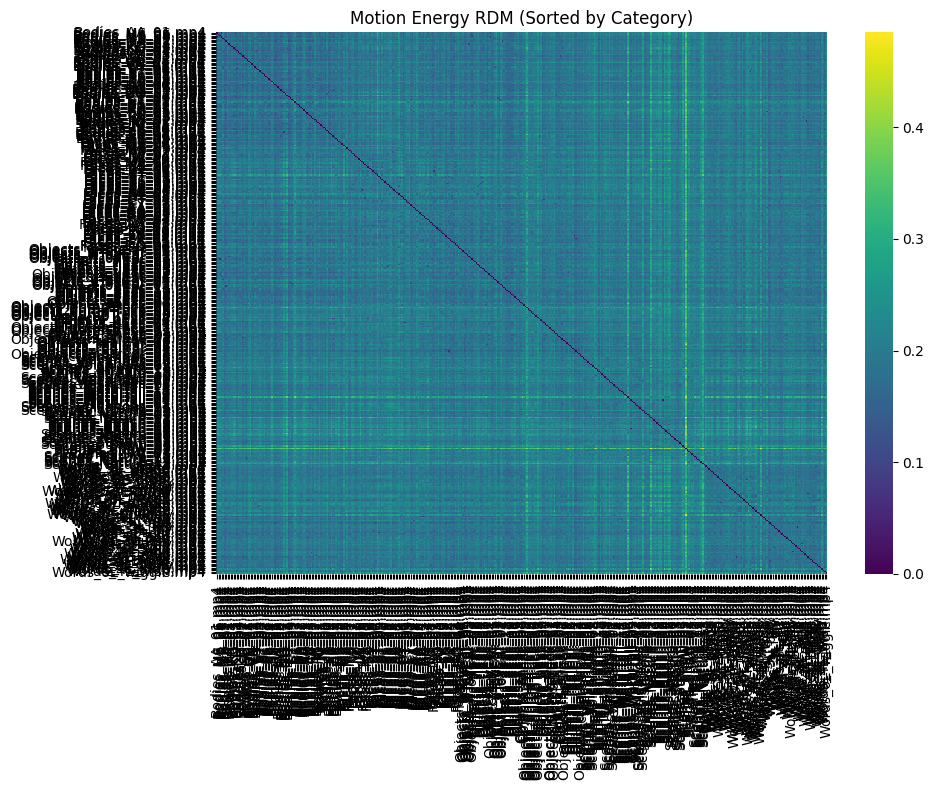

In [ ]:
# ----------------------
# MAIN PIPELINE
# ----------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

video_features = []         # full time-resolved features
video_representations = []  # mean features
video_labels = []
video_categories = []

for folder, category in target_folders.items():
    folder_path = os.path.join(base_dir, folder)
    if not os.path.isdir(folder_path):
        print(f"Skipping missing folder: {folder_path}")
        continue
    
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mp4'):
            video_path = os.path.join(folder_path, fname)
            print(f"Processing: {video_path}")
            try:
                features = process_video(video_path, nframes=nframes, fps=fps)
                video_features.append(features)  # shape: (n_frames, n_filters)
                video_representations.append(features.mean(axis=0))  # (n_filters,)
                video_labels.append(fname)
                video_categories.append(category)
            except Exception as e:
                print(f"Failed to process {fname}: {e}")


# Stack feature matrix
X = np.stack(video_representations)

# Sort by category
sorted_indices = np.argsort(video_categories)
X_sorted = X[sorted_indices]
labels_sorted = [video_labels[i] for i in sorted_indices]
cats_sorted = [video_categories[i] for i in sorted_indices]

# Check for NaNs
if np.isnan(X_sorted).any():
    raise ValueError("NaNs found in feature matrix — check your video processing.")

# Compute RDM using correlation distance
rdm = squareform(pdist(X_sorted, metric='correlation')) #could also use Euclidean or cosine distance, depends on various factors, can chat

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(rdm, xticklabels=labels_sorted, yticklabels=labels_sorted, cmap='viridis')
plt.title('Motion Energy RDM (Sorted by Category)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [17]:
import os
import numpy as np

# ----------------------
# SAVE RDM + METADATA + FEATURES
# ----------------------
save_dir = os.path.join(base_dir, "moten_motionenergy_rdm")
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "motion_energy_rdm_with_labels_and_X.npz")

np.savez_compressed(
    save_path,
    rdm=rdm.astype(np.float32),
    X_sorted=X_sorted.astype(np.float32),          # <-- important addition
    labels_sorted=np.array(labels_sorted),
    cats_sorted=np.array(cats_sorted),
    sorted_indices=sorted_indices.astype(np.int32),
    video_labels=np.array(video_labels),
    video_categories=np.array(video_categories),
)

print(f"Saved: {save_path}")


Saved: /Users/sedaakbiyik/Dropbox/Stanford/Projects/dyloc_development/stimuli_to_test/moten_motionenergy_rdm/motion_energy_rdm_with_labels_and_X.npz


In [18]:
import numpy as np

print("n videos:", len(video_features))
print("feature shape example:", video_features[0].shape)  # (n_frames, n_filters)

n_frames_set = sorted(set(f.shape[0] for f in video_features))
n_filters_set = sorted(set(f.shape[1] for f in video_features))
print("unique n_frames:", n_frames_set)
print("unique n_filters:", n_filters_set)

# per-video summary stats on mean reps
X = np.stack(video_representations)  # (n_videos, n_filters)
print("X shape:", X.shape)
print("Any NaNs:", np.isnan(X).any())

per_vid_energy = np.linalg.norm(X, axis=1)
print("Energy min/median/max:", per_vid_energy.min(), np.median(per_vid_energy), per_vid_energy.max())

# flag weird outliers
z = (per_vid_energy - per_vid_energy.mean()) / (per_vid_energy.std() + 1e-8)
out = np.where(np.abs(z) > 3)[0]
print("Energy outliers idx:", out[:20], "count:", len(out))


n videos: 400
feature shape example: (60, 2530)
unique n_frames: [58, 59, 60]
unique n_filters: [2530]
X shape: (400, 2530)
Any NaNs: False
Energy min/median/max: 142.19936 180.07364 197.97565
Energy outliers idx: [269 293] count: 2


In [19]:
# Threshold
z_thresh = 3.0

outlier_idx = np.where(np.abs(z) > z_thresh)[0]

print(f"\n⚠️ Energy outliers (|z| > {z_thresh}): {len(outlier_idx)}")

for i in outlier_idx:
    print(
        f"idx={i:3d} | "
        f"z={z[i]:+.2f} | "
        f"energy={per_vid_energy[i]:.2f} | "
        f"cat={video_categories[i]:7s} | "
        f"video={video_labels[i]}"
    )



⚠️ Energy outliers (|z| > 3.0): 2
idx=269 | z=-3.29 | energy=149.35 | cat=Scenes  | video=Scenes_Snow_01.mp4
idx=293 | z=-4.10 | energy=142.20 | cat=Scenes  | video=Scenes_Volcanoes_04.mp4


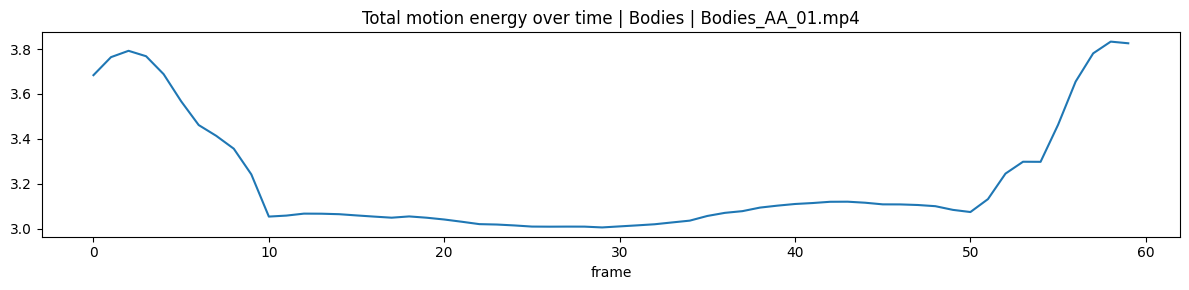

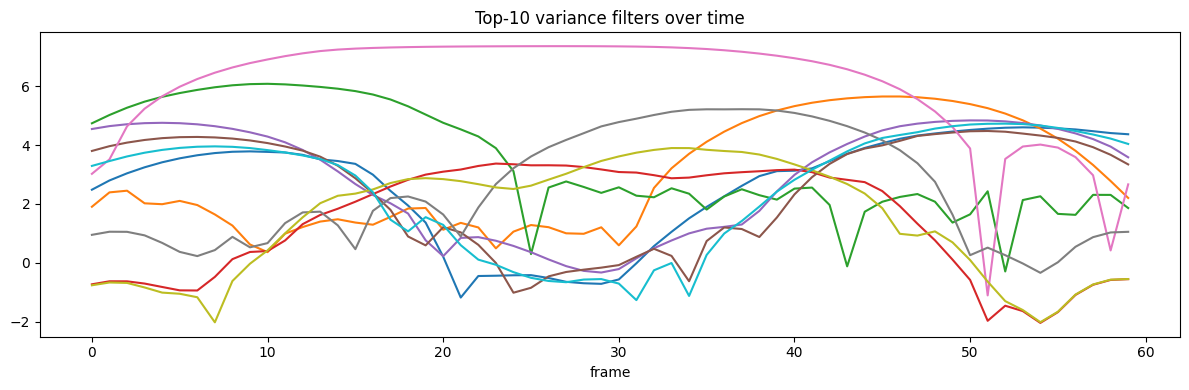

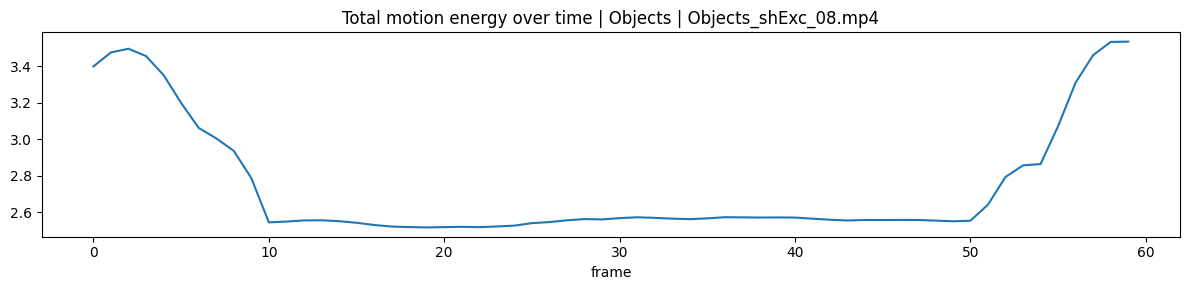

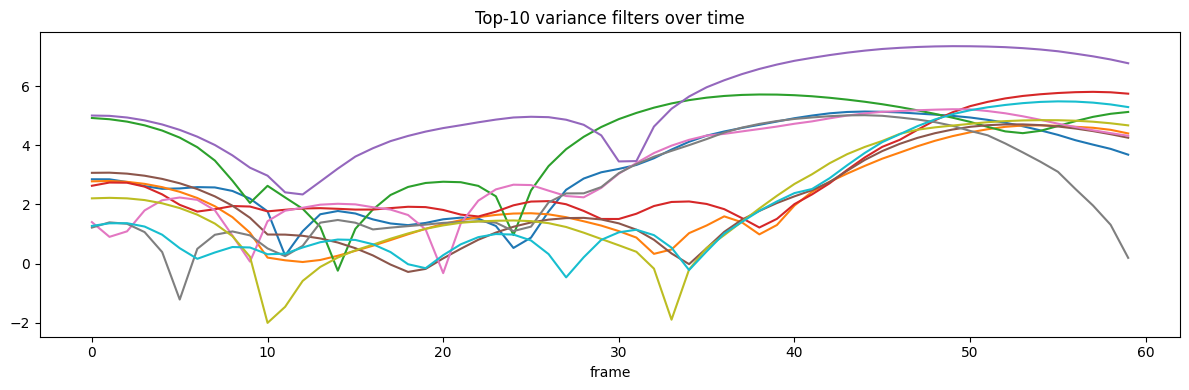

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_video_traces(i, k_filters=10):
    F = video_features[i]  # (T, D)
    T, D = F.shape
    t = np.arange(T)

    total = F.mean(axis=1)

    plt.figure(figsize=(12,3))
    plt.plot(t, total)
    plt.title(f"Total motion energy over time | {video_categories[i]} | {video_labels[i]}")
    plt.xlabel("frame")
    plt.tight_layout()
    plt.show()

    # plot a subset of filters (choose highest-variance filters for visibility)
    var = F.var(axis=0)
    idx = np.argsort(var)[-k_filters:]
    plt.figure(figsize=(12,4))
    plt.plot(t, F[:, idx])
    plt.title(f"Top-{k_filters} variance filters over time")
    plt.xlabel("frame")
    plt.tight_layout()
    plt.show()

# Try a few (or specific ones you suspect were affected by “tricks”)
plot_video_traces(0)
plot_video_traces(len(video_features)//2)


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

# ----------------------
# Desired category order
# ----------------------
cat_order = ["Faces", "Bodies", "Scenes", "Objects", "Words"]

# Category → color mapping
cat2color = {
    "Faces": "red",
    "Bodies": "gold",
    "Scenes": "green",
    "Objects": "brown",
    "Words": "blue",
}

# ----------------------
# REORDER an already-computed RDM + labels/categories
# (category order first, then filename within category)
# ----------------------
labels = np.array(labels_sorted)
cats   = np.array(cats_sorted)

cat_rank = {cat: i for i, cat in enumerate(cat_order)}

missing = sorted(set(cats) - set(cat_order))
if missing:
    raise ValueError(f"Found categories not in cat_order: {missing}")

cat_ranks = np.array([cat_rank[c] for c in cats])

# primary: cat_ranks, secondary: labels
new_order = np.lexsort((labels, cat_ranks))

rdm = rdm[np.ix_(new_order, new_order)]
labels_sorted = labels[new_order].tolist()
cats_sorted   = cats[new_order].tolist()

# Colors aligned with reordered labels
label_colors = [cat2color[c] for c in cats_sorted]

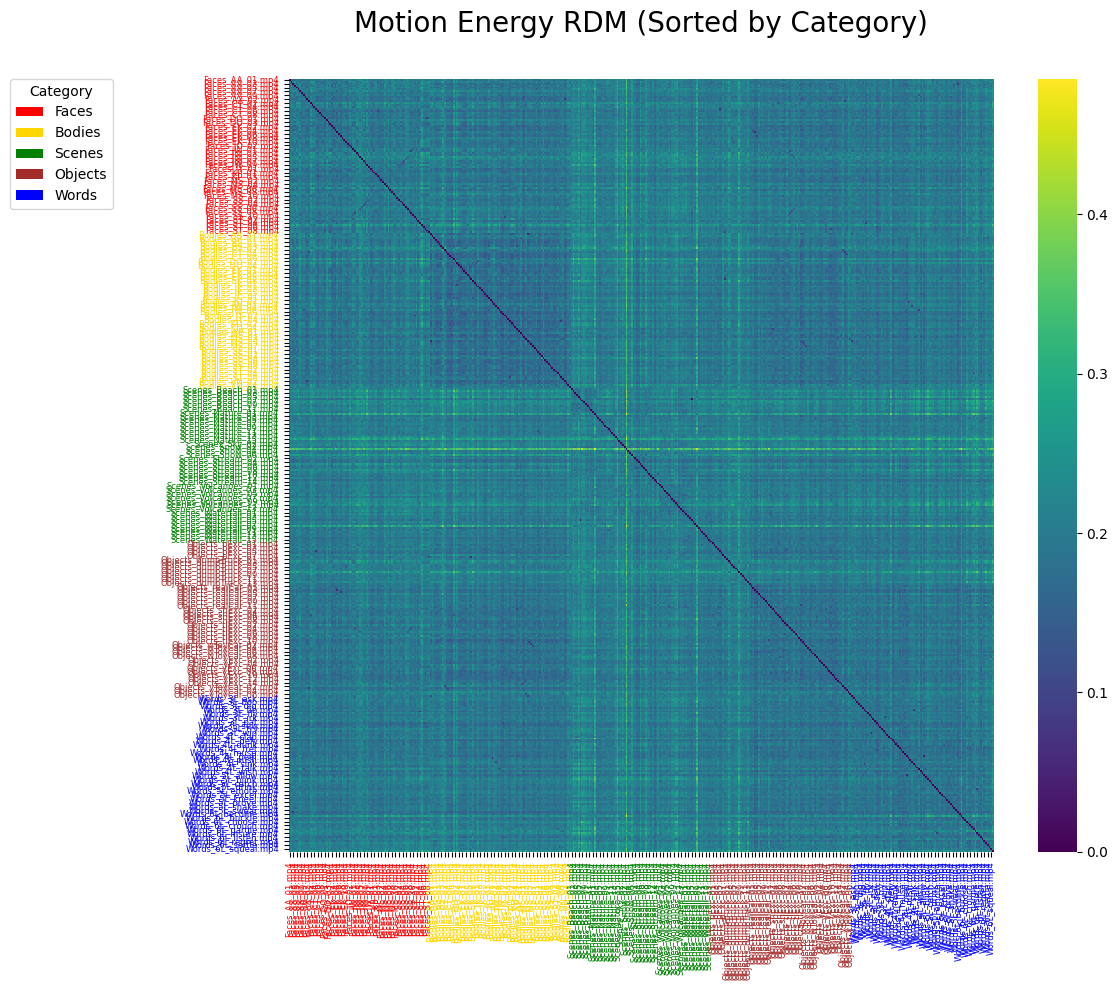

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np


# Plot heatmap (use rdm directly — already sorted)
plt.figure(figsize=(12, 10))
ax = sns.heatmap(rdm, xticklabels=False, yticklabels=False, cmap='viridis')

# Tick frequency
label_freq = 2  # show every Nth label
tick_indices = np.arange(len(labels_sorted))[::label_freq]

# X ticks
ax.set_xticks(tick_indices + 0.5)
ax.set_xticklabels(
    [labels_sorted[i] for i in tick_indices],
    rotation=90,
    fontsize=6
)
for xtick, i in zip(ax.get_xticklabels(), tick_indices):
    xtick.set_color(label_colors[i])

# Y ticks
ax.set_yticks(tick_indices + 0.5)
ax.set_yticklabels(
    [labels_sorted[i] for i in tick_indices],
    rotation=0,
    fontsize=6
)
for ytick, i in zip(ax.get_yticklabels(), tick_indices):
    ytick.set_color(label_colors[i])

# Legend
legend_elements = [Patch(facecolor=color, label=cat)
                   for cat, color in cat2color.items()]
ax.legend(
    handles=legend_elements,
    title="Category",
    bbox_to_anchor=(-0.25, 1),
    loc="upper right",
    borderaxespad=0
)

plt.title('Motion Energy RDM (Sorted by Category)', y=1.05, fontsize=20)
plt.tight_layout()
plt.savefig("moten_motion_rdm_all_categories_fewerlabels.png", dpi=300, bbox_inches='tight')
plt.show()


MDS on motion energy features

In [25]:
import numpy as np

def rdm_summary_stats(rdm, cats, name="RDM"):
    """
    Print summary stats for an RDM:
      - mean/std of upper triangle (excluding diagonal)
      - within-category and between-category mean ± std
    """
    rdm = np.asarray(rdm)
    cats = np.asarray(cats)

    assert rdm.ndim == 2 and rdm.shape[0] == rdm.shape[1], "rdm must be square"
    assert len(cats) == rdm.shape[0], "cats length must match rdm size"

    # Upper triangle (unique pairs)
    upper = rdm[np.triu_indices_from(rdm, k=1)]
    print(f"\n{name} — Summary Statistics")
    print(f"  dist min/mean/max: {upper.min():.6f}  {upper.mean():.6f}  {upper.max():.6f}")
    print(f"  dist std: {upper.std():.6f}")
    print(f"  approx corr mean (if dist=1-r): {(1-upper).mean():.6f}")

    # Within vs between
    within = []
    between = []
    n = len(cats)
    for i in range(n):
        for j in range(i+1, n):
            if cats[i] == cats[j]:
                within.append(rdm[i, j])
            else:
                between.append(rdm[i, j])

    within = np.asarray(within, dtype=np.float64)
    between = np.asarray(between, dtype=np.float64)

    if within.size and between.size:
        print(f"  within:  {within.mean():.6f} ± {within.std():.6f}   (n={within.size})")
        print(f"  between: {between.mean():.6f} ± {between.std():.6f}   (n={between.size})")
        print(f"  mean diff (between - within): {(between.mean()-within.mean()):.6f}")
    else:
        print("  (Not enough within or between pairs to compute split stats.)")

    # Basic sanity checks
    print(f"  diag mean/min/max: {np.mean(np.diag(rdm)):.6f}  {np.min(np.diag(rdm)):.6f}  {np.max(np.diag(rdm)):.6f}")
    print(f"  symmetry max abs: {np.max(np.abs(rdm - rdm.T)):.6e}")
    print(f"  NaNs? {np.isnan(rdm).any()}  Infs? {np.isinf(rdm).any()}")


In [27]:
rdm_summary_stats(rdm, cats_sorted, name="Other RDM")



Other RDM — Summary Statistics
  dist min/mean/max: 0.019062  0.201152  0.485017
  dist std: 0.031725
  approx corr mean (if dist=1-r): 0.798848
  within:  0.194875 ± 0.031993   (n=15800)
  between: 0.202701 ± 0.031467   (n=64000)
  mean diff (between - within): 0.007826
  diag mean/min/max: 0.000000  0.000000  0.000000
  symmetry max abs: 0.000000e+00
  NaNs? False  Infs? False


/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero 

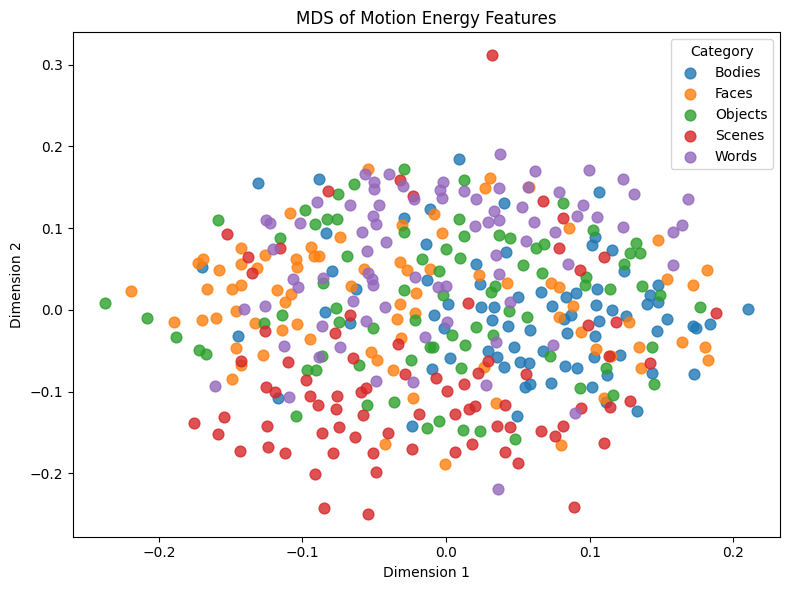

In [22]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import numpy as np

# Compute RDM again if needed
X = np.stack(video_representations)
sorted_indices = np.argsort(video_categories)
X_sorted = X[sorted_indices]
labels_sorted = [video_labels[i] for i in sorted_indices]
cats_sorted = [video_categories[i] for i in sorted_indices]

rdm = squareform(pdist(X_sorted, metric='correlation'))

# Run MDS (2D projection)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(rdm)

# Plot MDS with category coloring
plt.figure(figsize=(8, 6))

# Assign each category a unique color
unique_cats = sorted(set(cats_sorted))
cat_colors = {cat: plt.cm.tab10(i) for i, cat in enumerate(unique_cats)}

# Plot each point with appropriate color
for cat in unique_cats:
    idxs = [i for i, c in enumerate(cats_sorted) if c == cat]
    plt.scatter(coords[idxs, 0], coords[idxs, 1], label=cat, color=cat_colors[cat], s=60, alpha=0.8)

plt.title("MDS of Motion Energy Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Category", loc="best")
plt.tight_layout()
plt.show()


In [42]:
import os
import numpy as np
import moten
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------
# SETTINGS
# ----------------------
video_dir = 'trying_motionenergy'
nframes = 120
fps = 60

# ----------------------
# HELPERS
# ----------------------

def get_category(filename):
    for cat in ['Objects', 'Scenes', 'Faces', 'Bodies']:
        if cat in filename:
            return cat
    return 'Unknown'

def process_video(video_path, nframes=120, fps=60):
    luminance = moten.io.video2luminance(video_path, nimages=nframes)
    nimages, vdim, hdim = luminance.shape
    pyramid = moten.get_default_pyramid(vhsize=(vdim, hdim), fps=fps)
    features = pyramid.project_stimulus(luminance)
    return features.mean(axis=0)  # mean over time


In [ ]:
# ----------------------
# MAIN PIPELINE
# ----------------------
video_features = []  # this stores full frame-wise features
video_representations = []
video_labels = []
video_categories = []

for fname in sorted(os.listdir(video_dir)):
    if fname.endswith('.mp4'):
        video_path = os.path.join(video_dir, fname)
        print(f"Processing: {fname}")
        mean_feat = process_video(video_path, nframes=nframes, fps=fps)
        video_features.append(features)
        video_representations.append(mean_feat)
        video_labels.append(fname)
        video_categories.append(get_category(fname))


Processing: AA_Bodies-2.mp4


moten.io.video2luminance: 120it [00:12,  9.83it/s]
project_stimulus: 100%|██████████| 2530/2530 [02:42<00:00, 15.54it/s]


Processing: AA_Faces-4.mp4


moten.io.video2luminance: 48it [00:05,  9.43it/s]
project_stimulus: 100%|██████████| 2530/2530 [02:11<00:00, 19.20it/s]


Processing: Beaches_Scenes-3.mp4


...

moten.io.video2luminance: 48it [00:05,  9.11it/s]
project_stimulus: 100%|██████████| 2530/2530 [02:02<00:00, 20.58it/s]


Processing: wraceCar_Objects-5.mp4


moten.io.video2luminance: 48it [00:05,  9.32it/s]
project_stimulus: 100%|██████████| 2530/2530 [14:36<00:00,  2.89it/s]  


Processing: yExcavator_Objects-2.mp4


moten.io.video2luminance: 48it [00:05,  9.12it/s]
project_stimulus: 100%|██████████| 2530/2530 [02:04<00:00, 20.38it/s]


In [6]:
# Stack into feature matrix
X = np.stack(video_representations)

# Sort by category
sorted_indices = np.argsort(video_categories)
X_sorted = X[sorted_indices]
labels_sorted = [video_labels[i] for i in sorted_indices]
cats_sorted = [video_categories[i] for i in sorted_indices]

# Compute RDM
rdm = squareform(pdist(X_sorted, metric='correlation'))

# ----------------------
# PLOT RDM
# ----------------------

plt.figure(figsize=(10, 8))
sns.heatmap(rdm, xticklabels=labels_sorted, yticklabels=labels_sorted, cmap='viridis')
plt.title('Motion Energy RDM (Sorted by Category)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

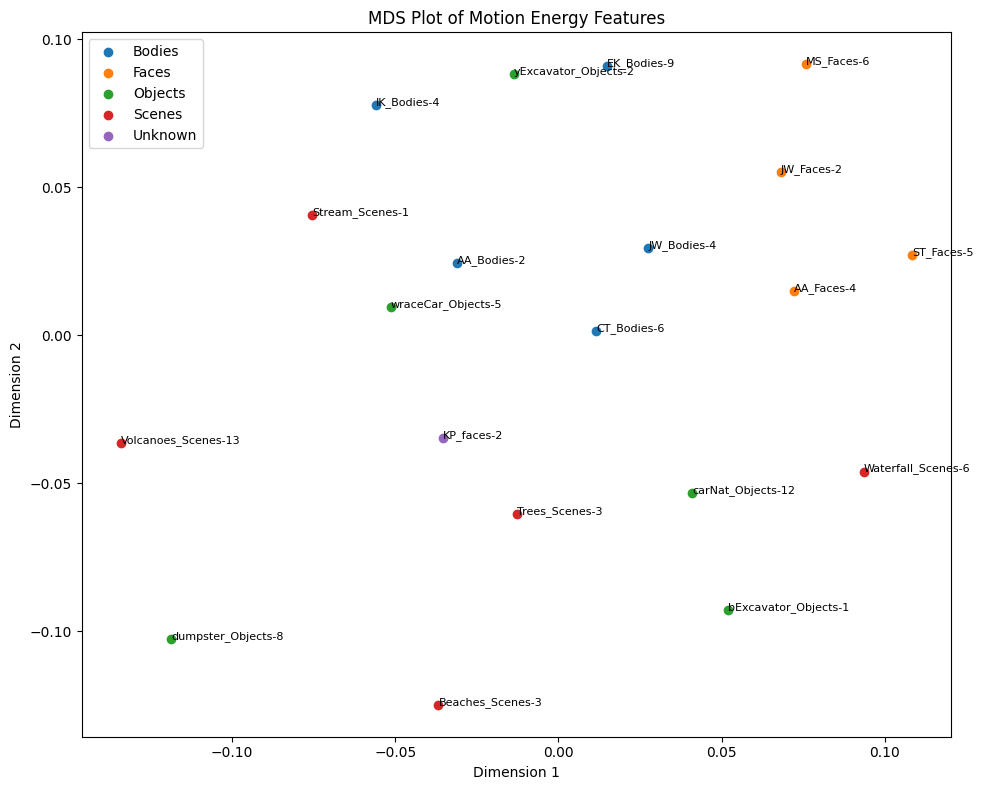

In [49]:
from sklearn.manifold import MDS

# Use correlation distance
from scipy.spatial.distance import pdist, squareform

dissimilarity_matrix = squareform(pdist(X_sorted, metric='correlation'))

# Run MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
mds_coords = mds.fit_transform(dissimilarity_matrix)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for cat in sorted(set(cats_sorted)):
    idxs = [i for i, c in enumerate(cats_sorted) if c == cat]
    plt.scatter(mds_coords[idxs, 0], mds_coords[idxs, 1], label=cat)

for i, label in enumerate(labels_sorted):
    plt.text(mds_coords[i, 0], mds_coords[i, 1], label.split('.')[0], fontsize=8)

plt.title('MDS Plot of Motion Energy Features')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()


/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sedaakbiyik/myenv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


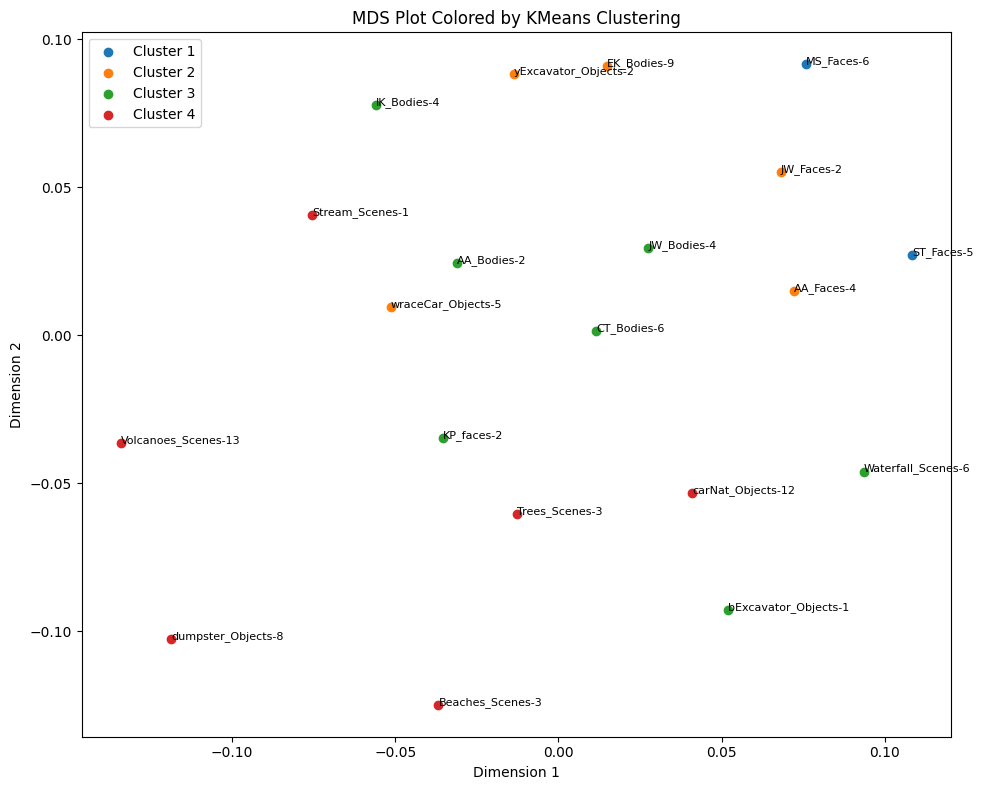

In [50]:
from sklearn.cluster import KMeans

n_clusters = 4  # You can also try different values
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_sorted)

# Plot MDS with cluster labels
plt.figure(figsize=(10, 8))
for cluster_id in range(n_clusters):
    idxs = np.where(cluster_labels == cluster_id)[0]
    plt.scatter(mds_coords[idxs, 0], mds_coords[idxs, 1], label=f'Cluster {cluster_id+1}')

for i, label in enumerate(labels_sorted):
    plt.text(mds_coords[i, 0], mds_coords[i, 1], label.split('.')[0], fontsize=8)

plt.title('MDS Plot Colored by KMeans Clustering')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()


In [52]:
from sklearn.metrics import adjusted_rand_score

# Map each category to a number
from sklearn.preprocessing import LabelEncoder
true_labels = LabelEncoder().fit_transform(cats_sorted)

ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")


Adjusted Rand Index (ARI): 0.218
